In [80]:
# !pip install pyreadstat
# !pip install numpy
# !pip install tensorflow
# !pip install pyreadstat
# !pip install tensorflow.python

### Ensuring reproducibility

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


### Libraries

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Recall
from keras_tuner import HyperModel, RandomSearch
import shap

## Load data

In [5]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test Split

In [6]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

# Artificial Neural Network

### Base model

In [7]:
# Define model architecture
ann_base = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile model
ann_base.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall')]
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = ann_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
262/262 [==============================] - 1s 2ms/step - loss: 0.6319 - accuracy: 0.6444 - recall: 0.5638 - val_loss: 0.5617 - val_accuracy: 0.7254 - val_recall: 0.6659
Epoch 2/100
262/262 [==============================] - 0s 2ms/step - loss: 0.5850 - accuracy: 0.7028 - recall: 0.6116 - val_loss: 0.5594 - val_accuracy: 0.7295 - val_recall: 0.5415
Epoch 3/100
262/262 [==============================] - 0s 2ms/step - loss: 0.5602 - accuracy: 0.7203 - recall: 0.5829 - val_loss: 0.5297 - val_accuracy: 0.7472 - val_recall: 0.7281
Epoch 4/100
262/262 [==============================] - 0s 2ms/step - loss: 0.5397 - accuracy: 0.7248 - recall: 0.6121 - val_loss: 0.5159 - val_accuracy: 0.7409 - val_recall: 0.6452
Epoch 5/100
262/262 [==============================] - 0s 2ms/step - loss: 0.5362 - accuracy: 0.7277 - recall: 0.5866 - val_loss: 0.5067 - val_accuracy: 0.7585 - val_recall: 0.6452
Epoch 6/100
262/262 [==============================] - 0s 2ms/step - loss: 0.5231 - accuracy: 0

### For better accuracy but has less recall

In [86]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

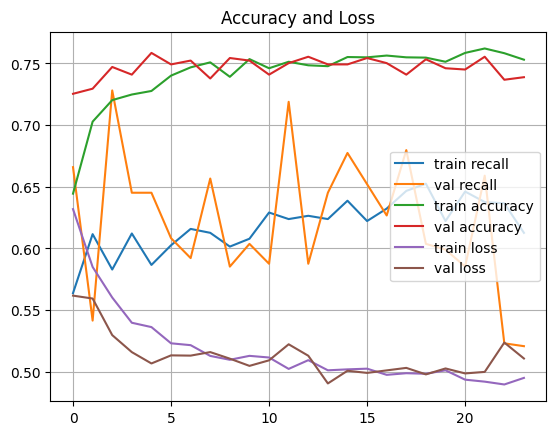

In [8]:
# Accuracies and losses
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Accuracy and Loss')
plt.show()

The training and validation curves in the plot indicate that the model is learning effectively, with both training and validation accuracy steadily improving and converging around 0.72. The training and validation loss curves also show expected behavior, with the training loss decreasing smoothly and validation loss initially dropping before slightly rising, suggesting a mild risk of overfitting after around 20 epochs. The recall on the training set gradually improves, indicating the model is increasingly successful at identifying malnourished children during training. However, the validation recall fluctuates significantly across epochs, which may point to model adjustments.

In [9]:
y_pred = (ann_base.predict(X_test) > 0.5).astype("int")
print(classification_report(y_test, y_pred))

41/41 [==============================] - 0s 939us/step
              precision    recall  f1-score   support

           0       0.74      0.83      0.79       707
           1       0.76      0.65      0.70       579

    accuracy                           0.75      1286
   macro avg       0.75      0.74      0.74      1286
weighted avg       0.75      0.75      0.75      1286



In [ ]:
# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_pred)}')

Average Precision: 0.6531331440811713


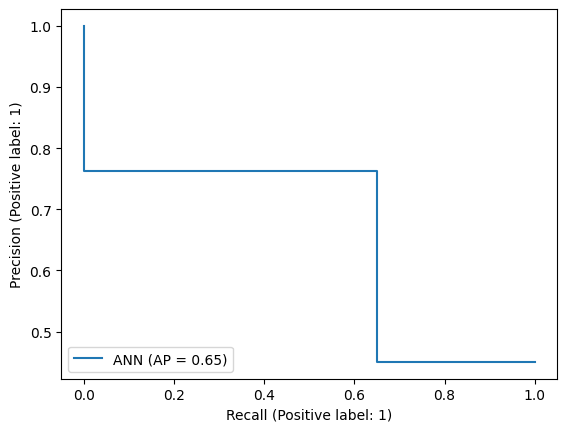

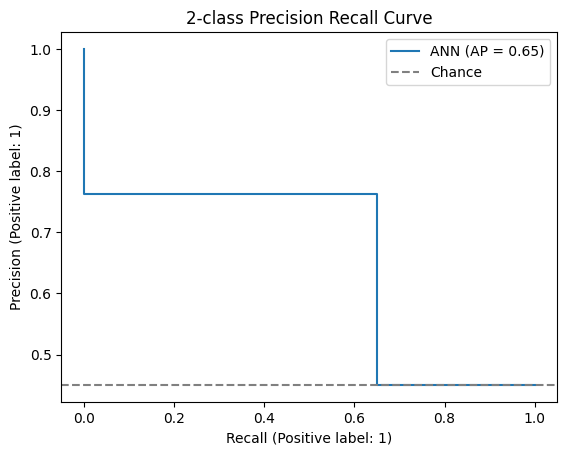

In [11]:
# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

# Hyperparameter Tuning

In [12]:
# Define a model builder function
def build_model(hp):
    ann = Sequential()

    # Add input layer
    ann.add(Input(shape=(X_train.shape[1],)))

    # First dense layer: tune number of neurons and dropout
    ann.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    ann.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    ann.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    ann.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return ann

In [14]:
# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),  # Focus on recall
    max_trials=5,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 00m 19s]
val_recall: 0.6889401078224182

Best val_recall So Far: 0.7442396283149719
Total elapsed time: 00h 01m 22s


In [15]:
ann_tuned = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

# Re-compile the best model before using it
ann_tuned.compile(
    optimizer=Adam(learning_rate=best_hps.get('learning_rate')),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall()]
)

In [16]:

# Evaluate or predict
y_pred_tuned = (ann_tuned.predict(X_test) > 0.5).astype("int")

print("Classification Report:\n", classification_report(y_test, y_pred_tuned))

41/41 [==============================] - 0s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.71      0.74       707
           1       0.68      0.75      0.71       579

    accuracy                           0.73      1286
   macro avg       0.73      0.73      0.73      1286
weighted avg       0.73      0.73      0.73      1286



In [17]:
print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

Best Hyperparameters:
units_1: 128
dropout_1: 0.2
units_2: 64
dropout_2: 0.1
learning_rate: 0.0005


41/41 [==============================] - 0s 879us/step


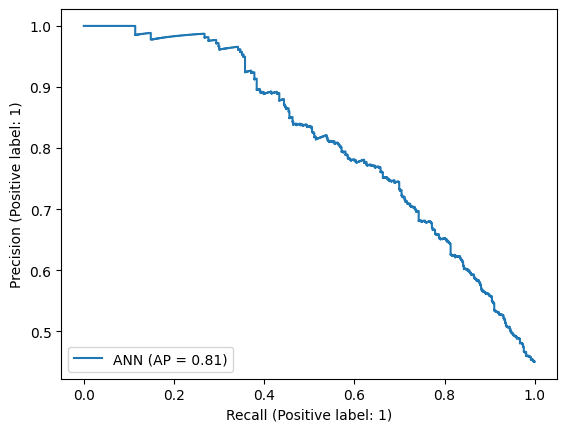

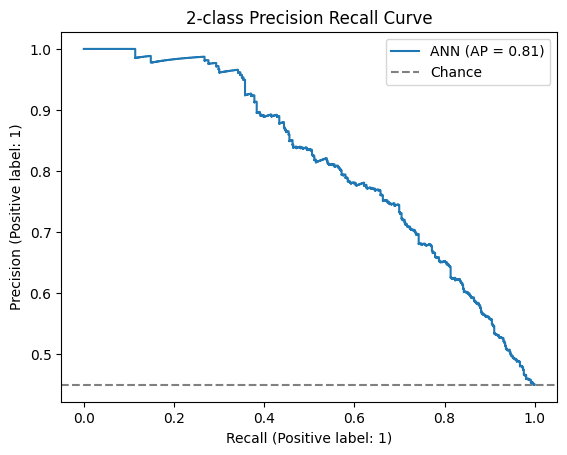

In [19]:
# Get predicted probabilities
y_probas = ann_tuned.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

41/41 [==============================] - 0s 778us/step


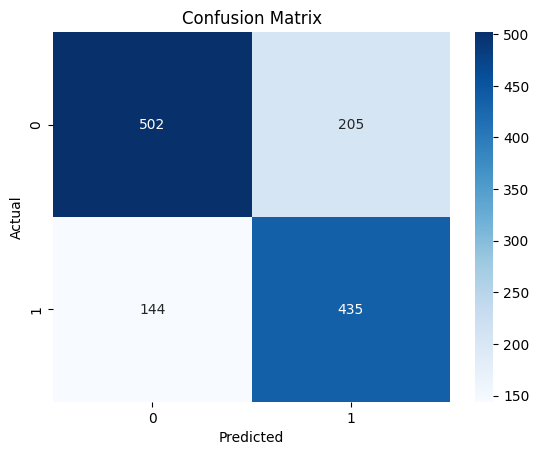

In [23]:
# Predict classes
y_prob = ann_tuned.predict(X_test)
# y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


37/37 [==============================] - 0s 1ms/step


PermutationExplainer explainer:   2%|▏         | 2/100 [00:00<?, ?it/s]

35/35 [==============================] - 0s 541us/step


PermutationExplainer explainer:   4%|▍         | 4/100 [00:12<01:19,  1.20it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [03:15<00:01,  1.90s/it]

35/35 [==============================] - 0s 850us/step


PermutationExplainer explainer: 100%|██████████| 100/100 [03:17<00:00,  1.87s/it]

35/35 [==============================] - 0s 889us/step


PermutationExplainer explainer: 101it [03:19,  2.01s/it]                         
C:\Users\dbastola2022\AppData\Local\Temp\ipykernel_15480\2075873878.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100])


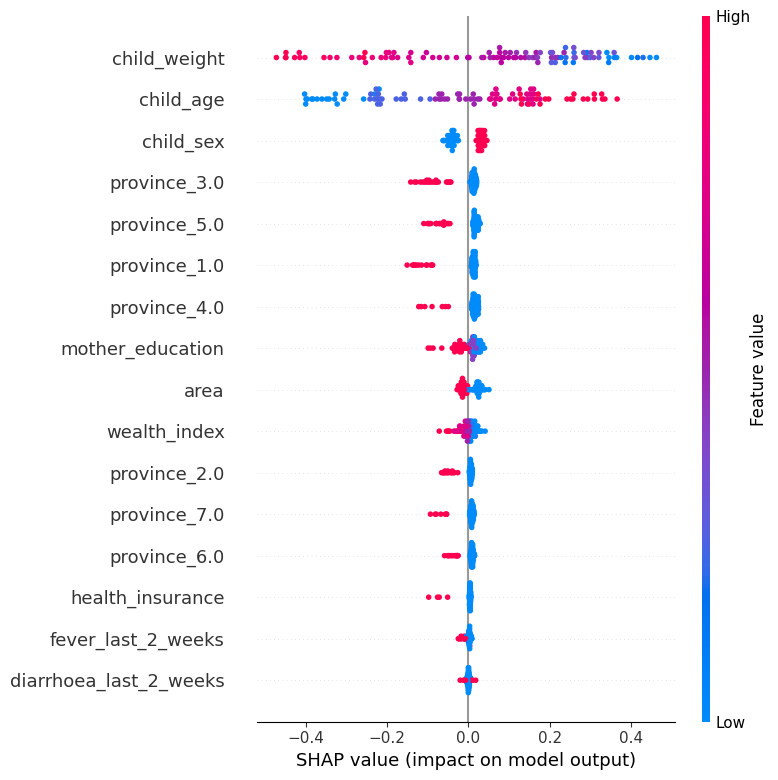

In [26]:
explainer = shap.Explainer(ann_tuned.predict, X_train)
shap_values = explainer(X_test[:100])  # Subset for speed

# Summary plot
shap.summary_plot(shap_values, X_test[:100])


### Additional

41/41 [==============================] - 0s 1ms/step


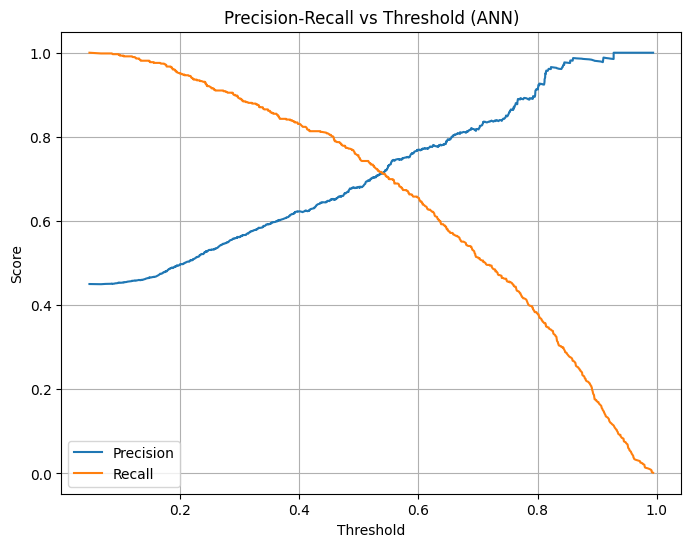

In [29]:
# Get predicted probabilities from Keras model
y_probas = ann_tuned.predict(X_test).flatten()

# Precision-Recall calculation
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (ANN)')
plt.grid(True)
plt.legend()
plt.show()

In [30]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.59      0.68       707
           1       0.62      0.83      0.71       579

    accuracy                           0.70      1286
   macro avg       0.72      0.71      0.70      1286
weighted avg       0.73      0.70      0.70      1286


